1\. Создайте тензор и исследуйте его основные характеристики

In [ ]:
import torch
#torch.rand(2) - массив 1 сторока, 2 числа
#torch.rand(2,3) - массив [[],[]] по 3 числа внутри
#t = torch.rand(2,3,4)# - [[[0.2979, 0.2972, 0.8576, 0.3573]
        # [0.6065, 0.7536, 0.8907, 0.3998],
         #[0.9417, 0.4129, 0.7339, 0.0037]],

        #[[0.7799, 0.8048, 0.5353, 0.9402],
         #[0.2919, 0.9592, 0.0290, 0.2074],
         #[0.0527, 0.1089, 0.6794, 0.8587]]]
t = torch.tensor(([0,1,2], [3,4,6]))
print(t.size(),t.dtype,t.shape,t.device, t.ndimension())

torch.Size([2, 3]) torch.int64 torch.Size([2, 3]) cpu 2


In [ ]:
t_ = torch.IntTensor(1,2)
t_

tensor([[157388720,         0]], dtype=torch.int32)

2\. Создайте трехмерный тензор и рассмотрите основные способы индексирования по нему

In [ ]:
t_3 = torch.rand(2,3,4)
t_3.ndimension()
print(t_3)
print("возврат тензора", t_3[0])
#print("возврат конкретного значения", t_3[0].item()) - ошибка Tensor with 12 elements cannot be converted to Scalar
print("возврат конкретного значения", t_3[0][0][0].item())
print("возврат тензора v2", t_3[1,1,1])

tensor([[[0.3660, 0.0553, 0.4633, 0.9338],
         [0.0907, 0.1646, 0.0963, 0.8010],
         [0.0279, 0.7844, 0.4707, 0.8739]],

        [[0.9361, 0.4370, 0.6714, 0.8101],
         [0.0764, 0.8601, 0.9726, 0.4583],
         [0.2919, 0.0584, 0.9279, 0.1401]]])
возврат тензора tensor([[0.3660, 0.0553, 0.4633, 0.9338],
        [0.0907, 0.1646, 0.0963, 0.8010],
        [0.0279, 0.7844, 0.4707, 0.8739]])
возврат конкретного значения 0.3659651279449463
возврат тензора v2 tensor(0.8601)


3\. Создайте тензор (4х4) и модифицируйте следующим образом: ко всем ч
етным столбцам прибавьте 1, из нечетных вычтите 1.

In [ ]:
t_4 = torch.arange(1,17).view(4,4)
t_4[:,2]
#t_4
for i in range(t_4.size(1)):
  if i%2 == 0:
    t_4[:,i] += 1
  else:
    t_4[:,i] -= 1
print(t_4)

tensor([[ 2,  1,  4,  3],
        [ 6,  5,  8,  7],
        [10,  9, 12, 11],
        [14, 13, 16, 15]])


<p class="task" id="1"></p>

1\. Создайте двумерный тензор размера (100000, 10), заполненный нулями. Используя прихотливое индексирование, поставьте в каждой строке тензора ровно одну единицу в случайно выбранном столбце. Рассчитайте и выведите на экран вероятности $p_i$ того, что для случайно выбранной строки в столбце $i$ будет стоять единица.

In [ ]:
import numpy as np

tensor = np.zeros((100000, 10))

rows = np.arange(tensor.shape[0])
cols = np.random.randint(0, tensor.shape[1], size=tensor.shape[0])

tensor[rows, cols] = 1

probabilities = np.sum(tensor, axis=0) / tensor.shape[0]

for i, p in enumerate(probabilities):
    print(f"Вероятность p_{i} того, что в столбце {i} будет стоять единица: {p:.4f}")


Вероятность p_0 того, что в столбце 0 будет стоять единица: 0.1002
Вероятность p_1 того, что в столбце 1 будет стоять единица: 0.0990
Вероятность p_2 того, что в столбце 2 будет стоять единица: 0.0994
Вероятность p_3 того, что в столбце 3 будет стоять единица: 0.1012
Вероятность p_4 того, что в столбце 4 будет стоять единица: 0.1008
Вероятность p_5 того, что в столбце 5 будет стоять единица: 0.1013
Вероятность p_6 того, что в столбце 6 будет стоять единица: 0.0990
Вероятность p_7 того, что в столбце 7 будет стоять единица: 0.0986
Вероятность p_8 того, что в столбце 8 будет стоять единица: 0.0994
Вероятность p_9 того, что в столбце 9 будет стоять единица: 0.1012


In [ ]:
np.random.randint(0, tensor.shape[1], size=tensor.shape[0])

array([3, 2, 8, ..., 8, 3, 5])

<p class="task" id="2"></p>

2\. При помощи прихотливого индексирования для двумерного тензора размерности (10, 10), состоящего из случайных целых чисел в пределах от 0 до 10, получите тензор элементов, находящихся сразу над побочной диагональю.

In [ ]:
t_2 = torch.randint(0, 11, (10, 10))


i_indices = torch.arange(9)
j_indices = 8 - i_indices

result = t_2[i_indices, j_indices]

print("Исходный тензор:\n", t_2)
print("Элементы над побочной диагональю:\n", result)


Исходный тензор:
 tensor([[ 2,  2,  9,  2,  6,  7, 10,  2,  7,  0],
        [ 3,  0,  2,  0,  0, 10,  6,  6,  2,  4],
        [ 1,  2,  3,  9,  5,  5,  6,  1,  9, 10],
        [ 2,  7,  7,  0,  7,  4,  9,  8,  3,  3],
        [ 4,  2,  4,  6,  3,  0, 10,  7,  9,  3],
        [ 9,  6,  2,  0,  2,  8,  5,  0,  9,  9],
        [ 7,  6, 10,  6,  4,  2,  8,  8,  0,  2],
        [ 7,  0,  0,  7,  9,  8,  6,  4,  5,  0],
        [ 2,  1,  5,  3,  1,  2, 10, 10,  3,  7],
        [ 1,  9,  9,  4,  5,  8,  6,  4,  2,  6]])
Элементы над побочной диагональю:
 tensor([ 7,  6,  6,  4,  3,  0, 10,  0,  2])


<p class="task" id="3"></p>

3\. Создайте двумерный тензор $t$ размерности (5, 5), состоящий из случайных чисел в пределах от 0 до 100. Обнулить все значения в массиве, расположенные вне квадрата размера 3х3 вокруг максимального элемента. Если максимумов несколько, обнулите элементы около любого из них.

In [ ]:
import torch

t = torch.randint(0, 101, (5, 5))
print("Исходный тензор:\n", t)

max_idx = torch.argmax(t)
max_i, max_j = divmod(max_idx.item(), 5)

for i in range(5):
    for j in range(5):
        if not (max_i - 1 <= i <= max_i + 1 and max_j - 1 <= j <= max_j + 1):
            t[i, j] = 0

print("Обработанный тензор:\n", t)


Исходный тензор:
 tensor([[ 21,  83,  18,  27,  82],
        [ 29,  67,  52,  52,  66],
        [ 65,  74,   3,  64,  41],
        [  9,  29,  98,  74,  20],
        [ 88, 100,  64,  79,  67]])
Обработанный тензор:
 tensor([[  0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0],
        [  9,  29,  98,   0,   0],
        [ 88, 100,  64,   0,   0]])


<p class="task" id="4"></p>

4\. Создайте трехмерный массив размерности (2, 5, 5) на основе решения задачи 3 (объедините исходный и результирущий тензор вдоль нулевой оси). Сохраните полученный трехмерный тензор в файл `tensor.pt`. Загрузите полученный тензор и покажите, что все элементы двух тензоров совпадают.

In [ ]:
import torch

t_5 = torch.randint(0, 101, (5, 5))

max_idx = torch.argmax(t_5)

max_i, max_j = divmod(max_idx.item(), 5)

start_i, start_j = max_i - 1, max_j - 1
end_i, end_j = max_i + 1, max_j + 1

t_5_modified = t_5.clone()
for i in range(t_5.size(0)):
    for j in range(t_5.size(1)):
        if not (start_i <= i <= end_i and start_j <= j <= end_j):
            t_5_modified[i, j] = 0

t_3d = torch.stack([t_5, t_5_modified], dim=0)

torch.save(t_3d, 'tensor.pt')

loaded_tensor = torch.load('tensor.pt')

print(torch.equal(t_3d, loaded_tensor))
print(loaded_tensor)

True
tensor([[[86, 94, 17,  1, 93],
         [42,  7, 30, 35, 28],
         [90, 67, 37, 29, 53],
         [42, 22, 54, 80, 45],
         [13, 96, 60, 84, 34]],

        [[ 0,  0,  0,  0,  0],
         [ 0,  0,  0,  0,  0],
         [ 0,  0,  0,  0,  0],
         [42, 22, 54,  0,  0],
         [13, 96, 60,  0,  0]]])


<ipython-input-24-272f9e6ba132>:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_tensor = torch.load('tensor.pt')


<p class="task" id="5"></p>

5\. Создайте четырехмерный массив `t` размерности (2, 3, 5, 5), заполненный случайными целыми числами от 1 до 10 (сами значения должны быть представлены типом float32). Рассчитайте среднее значение для каждого двумерного тензора `t[i, j, :, :]`. Представьте результат в виде трехмерного тензора размера (2, 3, 1).

In [ ]:
t = torch.randint(1, 11, size=(2, 3, 5, 5), dtype=torch.float32)

mean_values = torch.mean(t, dim=(2, 3)).unsqueeze(-1)

print("Исходный тензор t:")
print(t)
print("\nСредние значения для каждого двумерного тензора t[i, j, :, :]:")
print(mean_values)

Исходный тензор t:
tensor([[[[ 1.,  1.,  3.,  5.,  3.],
          [ 8.,  8.,  6.,  9.,  4.],
          [ 8.,  2., 10.,  1., 10.],
          [ 9.,  6.,  7.,  7., 10.],
          [ 7.,  7.,  1., 10.,  8.]],

         [[10.,  8.,  5.,  8., 10.],
          [ 2.,  1.,  2., 10.,  9.],
          [10.,  6.,  8., 10.,  1.],
          [ 8., 10.,  4.,  2.,  8.],
          [ 5.,  1.,  5.,  4.,  9.]],

         [[ 5.,  2.,  9.,  6.,  4.],
          [ 4.,  9.,  3.,  9.,  7.],
          [ 2.,  7.,  1.,  3.,  6.],
          [ 6.,  9.,  5.,  3.,  7.],
          [ 8., 10.,  1.,  7.,  3.]]],


        [[[ 7., 10.,  9.,  5.,  9.],
          [ 1., 10.,  6.,  9.,  5.],
          [ 5., 10.,  8.,  8.,  9.],
          [ 6.,  3.,  6.,  6.,  5.],
          [ 5., 10.,  7.,  4.,  3.]],

         [[ 8.,  6.,  5.,  3.,  6.],
          [ 4.,  6.,  5.,  7.,  3.],
          [ 8.,  9., 10.,  6.,  9.],
          [ 3.,  5.,  5.,  7.,  1.],
          [10.,  3.,  1.,  7.,  3.]],

         [[ 1.,  8.,  8., 10., 10.],
       

<p class="task" id="6"></p>

6\. Создайте одномерный тензор размера `N=100_000_000`, заполненный числами из экспоненциального распредления с параметром $\lambda=5$. Рассчитайте значения для построения гистограммы при помощи пакета `torch`. Визуализируйте гистограмму. Проверьте возможность использования GPU. При наличии GPU перенесите созданный тензор в память GPU, повторите вычисления. Сравните время расчетом с и без использования GPU.

Используемое устройство: cpu
Время создания тензора на CPU: 0.4076 секунд
Время расчета гистограммы на CPU: 0.6869 секунд


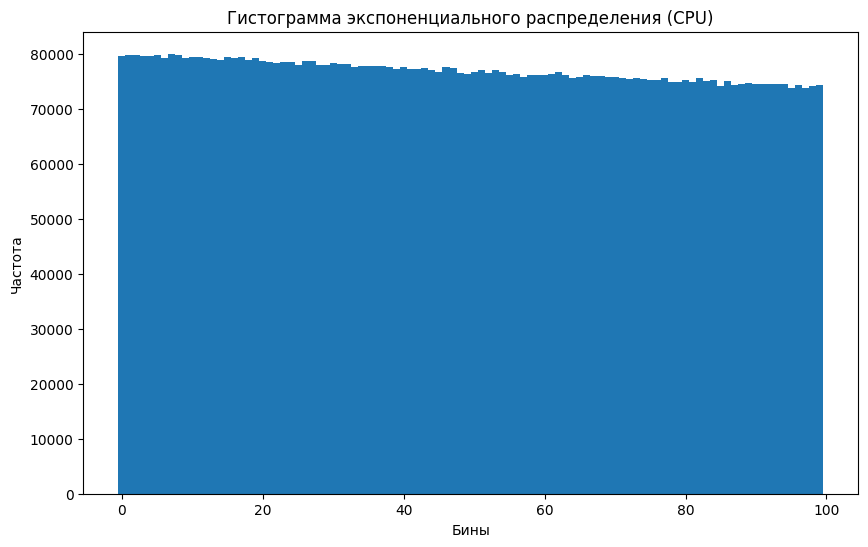

In [ ]:
import torch
import time
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")


N = 100_000_000
lambda_param = 5

start_time = time.time()
tensor_cpu = torch.empty(N, dtype=torch.float32).exponential_(1 / lambda_param)
print(f"Время создания тензора на CPU: {time.time() - start_time:.4f} секунд")

start_time = time.time()
hist_cpu = torch.histc(tensor_cpu, bins=100, min=0, max=2 / lambda_param)
print(f"Время расчета гистограммы на CPU: {time.time() - start_time:.4f} секунд")

plt.figure(figsize=(10, 6))
plt.bar(range(100), hist_cpu.numpy(), width=1.0)
plt.title("Гистограмма экспоненциального распределения (CPU)")
plt.xlabel("Бины")
plt.ylabel("Частота")
plt.show()

if device.type == "cuda":
    start_time = time.time()
    tensor_gpu = tensor_cpu.to(device)
    print(f"Время переноса тензора на GPU: {time.time() - start_time:.4f} секунд")

    start_time = time.time()
    hist_gpu = torch.histc(tensor_gpu, bins=100, min=0, max=2 / lambda_param)
    print(f"Время расчета гистограммы на GPU: {time.time() - start_time:.4f} секунд")

    plt.figure(figsize=(10, 6))
    plt.bar(range(100), hist_gpu.cpu().numpy(), width=1.0)
    plt.title("Гистограмма экспоненциального распределения (GPU)")
    plt.xlabel("Бины")
    plt.ylabel("Частота")
    plt.show()

<p class="task" id="7"></p>

7\. Создайте четырехмерный тензор размера (10, 6, 6, 3), заполненный случайными целыми числами от 0 до 255. Считая, что данный тензор представляет собой батч из 10 картинок размера 6х6 в формате RGB, измените тензор следующим образом. Для оттенков красного обнулите все столбцы, кроме первых двух; для оттенков зеленого обнулите столбцы со второго по четвертый; для оттенков синего обнулите пятый и шестой столбцы. Для выполнения задания используйте механизм распространения.

In [ ]:
import torch
tensor = torch.randint(0, 256, size=(10, 6, 6, 3), dtype=torch.int32)
modified_tensor = tensor.clone()

modified_tensor[:, :, 2:, 0] = 0
modified_tensor[:, :, 1:4, 1] = 0
modified_tensor[:, :, 4:, 2] = 0

print("Исходный тензор (первое изображение):")
print(tensor[0, :, :, :])
print("\nИзмененный тензор (первое изображение):")
print(modified_tensor[0, :, :, :])

Исходный тензор (первое изображение):
tensor([[[131, 224,  72],
         [ 65,  73,  22],
         [238, 211,  21],
         [158, 206,  48],
         [218,  65, 227],
         [228,  14,   8]],

        [[  4,  68,  25],
         [ 87, 191, 208],
         [ 14, 215,  68],
         [169, 152, 113],
         [223, 181, 102],
         [202,  11,  59]],

        [[ 98, 202, 106],
         [ 72, 253,  16],
         [185,  92, 236],
         [ 20,  59, 244],
         [216,  28, 221],
         [157,  80, 228]],

        [[ 24, 179,  80],
         [174, 183, 248],
         [248, 182, 190],
         [188, 208, 104],
         [ 50, 186, 100],
         [217, 163, 159]],

        [[171, 156, 250],
         [235, 157,  97],
         [ 76,  84,  13],
         [ 45, 192, 116],
         [119, 151, 178],
         [104, 162, 208]],

        [[ 81, 178, 253],
         [ 34, 172, 127],
         [ 30, 161, 107],
         [126,  82, 204],
         [240,  29,  58],
         [ 50, 189, 172]]], dtype=torch.in

## Обратная связь
- [ ] Хочу получить обратную связь по решению